In [1]:
import matplotlib.pyplot as plt
from src.load_data import *
from tensorflow.keras.models import load_model

/Users/yugamdeepgoyal/my_gpu/tf_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_images, train_labels, test_images, test_labels = get_dataset()

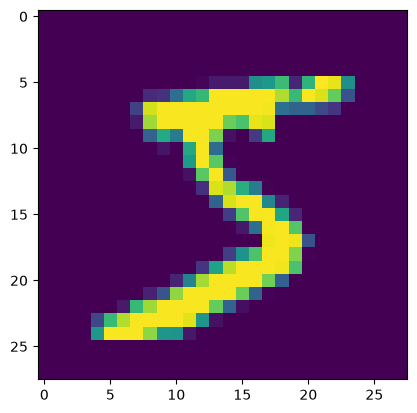

In [3]:
plt.imshow(train_images[0])

In [4]:
train_images.shape[1:]

(28, 28)

In [5]:
model = load_model("models/mnist_ann_model.keras")

2026-07-19 21:50:33.064846: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-07-19 21:50:33.064883: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-07-19 21:50:33.064897: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-07-19 21:50:33.064922: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-19 21:50:33.064942: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 368)            │       288,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 368)            │         1,472 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 160)            │        59,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 384)            │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         3,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,248,080 (4.76 MB)

 Trainable params: 415,418 (1.58 MB)

 Non-trainable params: 1,824 (7.12 KB)

 Optimizer params: 830,838 (3.17 MB)

In [7]:
# Normalize
X_train = train_images.astype("float32") / 255.0
X_test = test_images.astype("float32") / 255.0

In [8]:
test_loss, test_acc = model.evaluate(X_test, test_labels)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

2026-07-19 21:50:33.565306: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9858 - loss: 0.0916
Test accuracy: 0.9858
Test loss: 0.0916


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


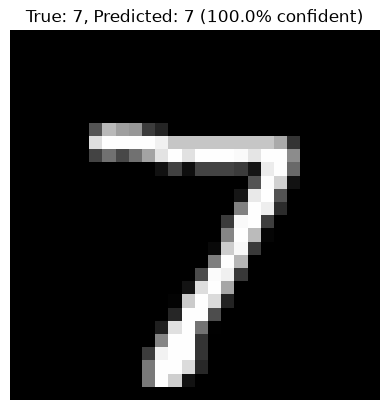

In [9]:
import matplotlib.pyplot as plt

index = 0  # try any index
img = X_test[index]
true_label = test_labels[index]

prediction = model.predict(img.reshape(1, 28, 28))
predicted_label = np.argmax(prediction)
confidence = np.max(prediction) * 100

plt.imshow(img, cmap='gray')
plt.title(f"True: {true_label}, Predicted: {predicted_label} ({confidence:.1f}% confident)")
plt.axis('off')
plt.show()

In [22]:
def preprocess_phone_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.bitwise_not(img)
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Stronger dilation to ensure both strokes are equally bold
    kernel = np.ones((4, 4), np.uint8)
    img = cv2.dilate(img, kernel, iterations=2)

    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = [c for c in contours if cv2.contourArea(c) > 20]
    all_points = np.vstack(contours)
    x, y, w, h = cv2.boundingRect(all_points)
    img = img[y:y+h, x:x+w]

    size = max(w, h)
    square = np.zeros((size, size), dtype=np.uint8)
    square[(size-h)//2:(size-h)//2+h, (size-w)//2:(size-w)//2+w] = img
    img = cv2.resize(square, (20, 20), interpolation=cv2.INTER_AREA)

    # RE-THRESHOLD after resize to remove blurry gray edges introduced by resizing
    _, img = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)

    padded = np.zeros((28, 28), dtype=np.uint8)
    padded[4:24, 4:24] = img

    cy, cx = ndimage.center_of_mass(padded)
    shift_x = int(round(14 - cx))
    shift_y = int(round(14 - cy))
    padded = ndimage.shift(padded, (shift_y, shift_x), mode='constant', cval=0)

    # RE-THRESHOLD again after shift (shifting can also introduce blur/interpolation)
    padded = np.where(padded > 100, 255, 0).astype(np.uint8)

    return padded.astype("float32") / 255.0

In [23]:
predict_digit("predict.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


(1,
 100.0,
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.

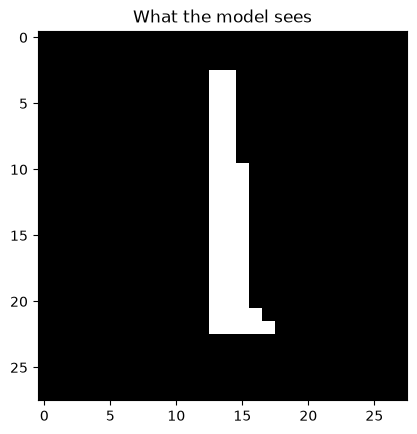

In [24]:
import matplotlib.pyplot as plt

processed = preprocess_phone_image("predict.jpeg")
plt.imshow(processed, cmap='gray')
plt.title("What the model sees")
plt.show()